In [51]:
%matplotlib inline
import torch
from d2l import torch as d2l

torch.set_printoptions(2)  # 精简输出精度

13.4.1. 生成多个锚框

设置s,r生成一组锚框，这算是超参数

In [52]:
#@save
def multibox_prior(data, sizes, ratios):
    
    """生成以每个像素为中心具有不同形状的锚框"""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1)#每个像素点这么多锚框
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)
    
     # 为了将锚点移动到像素的中心，需要设置偏移量。
    # 因为一个像素的高为1且宽为1，我们选择偏移我们的中心0.5
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height  # 在y轴上缩放步长
    steps_w = 1.0 / in_width  # 在x轴上缩放步长
        # 生成锚框的所有中心点
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    #索引配对就是所有的中心点
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)
    
        # 生成“boxes_per_pixel”个高和宽，
    # 之后用于创建锚框的四角坐标(xmin,xmax,ymin,ymax)
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),
                   sizes[0] * torch.sqrt(ratio_tensor[1:])))\
                   * in_height / in_width  # 处理矩形输入
    
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),
                   sizes[0] / torch.sqrt(ratio_tensor[1:])))
    #不同中锚框的偏移，然后复制到所有像素点上
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
                                    in_height * in_width, 1) / 2
    
     # 每个中心点都将有“boxes_per_pixel”个锚框，
    # 所以生成含所有锚框中心的网格，重复了“boxes_per_pixel”次
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
            dim=1).repeat_interleave(boxes_per_pixel, dim=0)
    
    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)#batch_size,总锚框数,4

In [53]:
out_grid_temp= [
    [0.5, 0.25, 0.5, 0.25],  # 中心点0，锚框1
    [0.5, 0.25, 0.5, 0.25],  # 中心点0，锚框2
    [0.5, 0.75, 0.5, 0.75],  # 中心点1，锚框1
    [0.5, 0.75, 0.5, 0.75]   # 中心点1，锚框2
]
# 形状: (4, 4)

In [54]:
img = d2l.plt.imread(r'E:\classify-leaves\images\122.jpg')
h, w = img.shape[:2]
print(h, w)
X = torch.rand(size=(1, 3, h, w))
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
Y.shape

224 224


torch.Size([1, 250880, 4])

In [55]:
boxes = Y.reshape(h, w, 5, 4)
boxes[200, 200, 0, :]

tensor([0.52, 0.52, 1.27, 1.27])

In [56]:
#@save
def show_bboxes(axes, bboxes, labels=None, colors=None):
    """显示所有边界框"""
    def _make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = _make_list(labels)
    colors = _make_list(colors, ['b', 'g', 'r', 'm', 'c'])
    for i, bbox in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = d2l.bbox_to_rect(bbox.detach().numpy(), color)
        axes.add_patch(rect)
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w'
            axes.text(rect.xy[0], rect.xy[1], labels[i],
                      va='center', ha='center', fontsize=9, color=text_color,
                      bbox=dict(facecolor=color, lw=0))

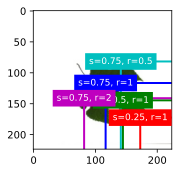

In [57]:
d2l.set_figsize()
bbox_scale = torch.tensor((w, h, w, h))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes[200, 200, :, :] * bbox_scale,
            ['s=0.75, r=1', 's= 0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

13.4.2. 交并比（IoU）

In [58]:
#@save
def box_iou(boxes1, boxes2):
    """计算两个锚框或边界框列表中成对的交并比"""
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) *
                              (boxes[:, 3] - boxes[:, 1]))
    
    # boxes1,boxes2,areas1,areas2的形状:
    # boxes1：(boxes1的数量,4),
    # boxes2：(boxes2的数量,4),
    # areas1：(boxes1的数量,),
    # areas2：(boxes2的数量,)
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)
    # inter_upperlefts,inter_lowerrights,inters的形状:
    # (boxes1的数量,boxes2的数量,2)
    
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])#这是个相容性的技巧
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)
    # inter_areasandunion_areas的形状:(boxes1的数量,boxes2的数量)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    union_areas = areas1[:, None] + areas2 - inter_areas
    
    return inter_areas / union_areas

13.4.3. 在训练数据中标注锚框

13.4.3.1. 将真实边界框分配给锚框

In [59]:
#@save
def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """将最接近的真实边界框分配给锚框"""
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    # 位于第i行和第j列的元素x_ij是锚框i和真实边界框j的IoU
    
    jaccard = box_iou(anchors, ground_truth)#计算iou
    
    # 对于每个锚框，分配的真实边界框的张量
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long,
                                  device=device)#锚框的数量
    # 根据阈值，决定是否分配真实边界框
    max_ious, indices = torch.max(jaccard, dim=1)
    
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)#所有大于阈值的锚框索引
    box_j = indices[max_ious >= iou_threshold]#大于阈值的真实框索引
    
    anchors_bbox_map[anc_i] = box_j#建立映射
    
    #建立分配
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    
    for _ in range(num_gt_boxes):
        max_idx = torch.argmax(jaccard)#它是展开后的最大索引
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx / num_gt_boxes).long()
        
        anchors_bbox_map[anc_idx] = box_idx
        
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
        
    return anchors_bbox_map

13.4.3.2. 标记类别和偏移量

In [60]:
#@save
def offset_boxes(anchors, assigned_bb, eps=1e-6):
    """对锚框偏移量的转换"""
    
    #对锚框和真实框都转化为中心宽高的形式
    c_anc = d2l.box_corner_to_center(anchors)
    c_assigned_bb = d2l.box_corner_to_center(assigned_bb)
    
    #中心点的偏移除以真实框的宽高
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    #拼接起来
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    return offset

In [61]:
#@save
def multibox_target(anchors, labels):
    """使用真实边界框标记锚框"""
    #形状：(批量大小，锚框数量，4)
    # 形状：(批量大小，真实框数量，5)
    
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    
    batch_offset, batch_mask, batch_class_labels = [], [], []#每个样本的偏移量，偏移量掩码，类型
    
    device, num_anchors = anchors.device, anchors.shape[0]
    
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox(
            label[:, 1:], anchors, device)
        
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(
            1, 4)#标记哪些锚框参与偏移量损失计算（1参与，0不参与）
         
        # 将类标签和分配的边界框坐标初始化为零
        class_labels = torch.zeros(num_anchors, dtype=torch.long,
                                   device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32,
                                  device=device)
        
        # 使用真实边界框来标记锚框的类别。
        # 如果一个锚框没有被分配，标记其为背景（值为零）
        indices_true = torch.nonzero(anchors_bbox_map >= 0)#返回的锚框索引
        
        bb_idx = anchors_bbox_map[indices_true]#这是真实框索引
        
        class_labels[indices_true] = label[bb_idx, 0].long() + 1#把0留给背景类
        assigned_bb[indices_true] = label[bb_idx, 1:]#为正样本锚框填充对应的真实边界框坐标。
        # 偏移量转换
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask#返回真正匹配锚框的偏移量
        
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
        
    bbox_offset = torch.stack(batch_offset)
    bbox_mask = torch.stack(batch_mask)
    class_labels = torch.stack(batch_class_labels)
    #所有锚框的偏移量，但只有匹配到真实框的锚框的偏移量是有效值（通过偏移量公式计算），未匹配的锚框的偏移量被设为 0。(批量大小，锚框数量 × 4)
    #那些是匹配到的锚框，(批量大小，锚框数量 × 4)
    #匹配到的对应标签，(批量大小，锚框数量)
    return (bbox_offset, bbox_mask, class_labels)

13.4.3.3. 一个例子

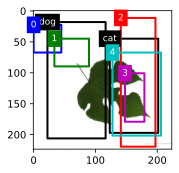

In [62]:
ground_truth = torch.tensor([[0, 0.1, 0.08, 0.52, 0.92],
                         [1, 0.55, 0.2, 0.9, 0.88]])
anchors = torch.tensor([[0, 0.1, 0.2, 0.3], [0.15, 0.2, 0.4, 0.4],
                    [0.63, 0.05, 0.88, 0.98], [0.66, 0.45, 0.8, 0.8],
                    [0.57, 0.3, 0.92, 0.9]])
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, ground_truth[:, 1:] * bbox_scale, ['dog', 'cat'], 'k')
show_bboxes(fig.axes, anchors * bbox_scale, ['0', '1', '2', '3', '4']);

In [63]:
labels = multibox_target(anchors.unsqueeze(dim=0),
                         ground_truth.unsqueeze(dim=0))

In [64]:
labels[2]

tensor([[0, 1, 2, 0, 2]])

返回的第二个元素是掩码（mask）变量，形状为（批量大小，锚框数的四倍）。 掩码变量中的元素与每个锚框的4个偏移量一一对应。 由于我们不关心对背景的检测，负类的偏移量不应影响目标函数。 通过元素乘法，掩码变量中的零将在计算目标函数之前过滤掉负类偏移量。

In [65]:
labels[1]

tensor([[0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1.,
         1., 1.]])

返回的第一个元素包含了为每个锚框标记的四个偏移值。 请注意，负类锚框的偏移量被标记为零。

In [66]:
labels[0]

tensor([[-0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00,  1.40e+00,  1.00e+01,
          2.59e+00,  7.18e+00, -1.20e+00,  2.69e-01,  1.68e+00, -1.57e+00,
         -0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00, -5.71e-01, -1.00e+00,
          4.17e-06,  6.26e-01]])

13.4.4. 使用非极大值抑制预测边界框

In [67]:
#@save
def offset_inverse(anchors, offset_preds):
    """根据带有预测偏移量的锚框来预测边界框"""
    
    #将模型预测的偏移量转换回边界框坐标
    anc = d2l.box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    predicted_bbox = d2l.box_center_to_corner(pred_bbox)
    return predicted_bbox

In [68]:
#@save
def nms(boxes, scores, iou_threshold):
    """对预测边界框的置信度进行排序"""
    #预测的边界框（角点格式）
    #每个预测框的分数,也就是概率的最大值，置信度
    #iou阈值
    B = torch.argsort(scores, dim=-1, descending=True)#按分数降序，返回索引
    keep = []  # 保留预测边界框的指标
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1: break
        
         # 2. 计算最高分框与其他框的IoU
        iou = box_iou(boxes[i, :].reshape(-1, 4),
                      boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        
         # 3. 找出IoU ≤ 阈值的框（不重叠或重叠少的）
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        
         # 4. 更新B，只保留这些框（+1是因为跳过了第一个）吗，第另个是最大的
        B = B[inds + 1]
    return torch.tensor(keep, device=boxes.device)

模型的核心任务就是输出每个锚框对应的偏移量。


In [69]:
#@save
def multibox_detection(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                       pos_threshold=0.009999999):
    
    """使用非极大值抑制来预测边界框"""
    #(batch_size, num_classes+1, num_anchors)，对于每个类别，有 num_anchors 个概率值（每个锚框一个）
    #	(batch_size, num_anchors×4)，预测的偏移量
    #	(1, num_anchors, 4) 锚框
    #阈值
    #	置信度阈值
    
    #初始化
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)#去除批次维度
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    
    
    out = []
    
    
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        
        conf, class_id = torch.max(cls_prob[1:], 0)#置信度与相对类别索引
        
        predicted_bb = offset_inverse(anchors, offset_pred)#将预测的偏移量解码成真实的边界框坐标
        
        keep = nms(predicted_bb, conf, nms_threshold)#保留预测边框的指标

        # 找到所有的non_keep索引，并将类设置为背景
        
        #创建所有锚框的索引
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)

        combined = torch.cat((keep, all_idx))
    
    #找出被删除的框
        uniques, counts = combined.unique(return_counts=True)#返回每个唯一值出现的次数
        
        non_keep = uniques[counts == 1]
        
        all_id_sorted = torch.cat((keep, non_keep))#把保留的框放在前面，删除的框放在后面
        class_id[non_keep] = -1#将被NMS删除的框的类别设为 -1
        
        #重排
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        
        # pos_threshold是一个用于非背景预测的阈值
        below_min_idx = (conf < pos_threshold)
        
        class_id[below_min_idx] = -1  #抑制
        
        conf[below_min_idx] = 1 - conf[below_min_idx]#翻转低置信度
        
        pred_info = torch.cat((class_id.unsqueeze(1),
                               conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)#[类别, 置信度, x1, y1, x2, y2]
        
    return torch.stack(out)

In [70]:
anchors = torch.tensor([[0.1, 0.08, 0.52, 0.92], [0.08, 0.2, 0.56, 0.95],
                      [0.15, 0.3, 0.62, 0.91], [0.55, 0.2, 0.9, 0.88]])
offset_preds = torch.tensor([0] * anchors.numel())
cls_probs = torch.tensor([[0] * 4,  # 背景的预测概率
                      [0.9, 0.8, 0.7, 0.1],  # 狗的预测概率
                      [0.1, 0.2, 0.3, 0.9]])  # 猫的预测概率

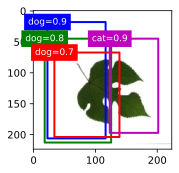

In [71]:
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, anchors * bbox_scale,
            ['dog=0.9', 'dog=0.8', 'dog=0.7', 'cat=0.9'])

In [72]:
output = multibox_detection(cls_probs.unsqueeze(dim=0),
                            offset_preds.unsqueeze(dim=0),
                            anchors.unsqueeze(dim=0),
                            nms_threshold=0.5)
output

tensor([[[ 0.00,  0.90,  0.10,  0.08,  0.52,  0.92],
         [ 1.00,  0.90,  0.55,  0.20,  0.90,  0.88],
         [-1.00,  0.80,  0.08,  0.20,  0.56,  0.95],
         [-1.00,  0.70,  0.15,  0.30,  0.62,  0.91]]])

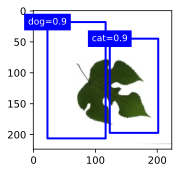

In [73]:
fig = d2l.plt.imshow(img)
for i in output[0].detach().numpy():
    if i[0] == -1:
        continue
    label = ('dog=', 'cat=')[int(i[0])] + str(i[1])
    show_bboxes(fig.axes, [torch.tensor(i[2:]) * bbox_scale], label)